In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.optim as optim
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
ticker = "AAPL"
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400
2020-01-03,71.763733,72.523762,71.539345,71.696175,146322800
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153511,73.455110,71.698596,71.698596,132079200
...,...,...,...,...,...
2025-12-17,271.839996,276.160004,271.640015,275.010010,50138700
2025-12-18,272.190002,273.630005,266.950012,273.609985,51630700


<Axes: xlabel='Date'>

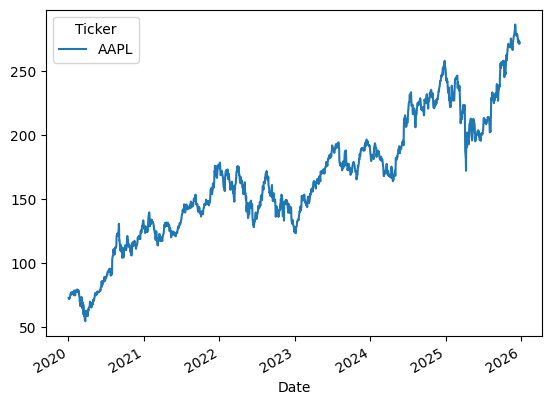

In [5]:
df.Close.plot()

In [6]:
scaler = StandardScaler()

df["Close"] = scaler.fit_transform(df["Close"])

In [7]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.865002
2020-01-03,-1.879267
2020-01-06,-1.867689
2020-01-07,-1.874577
2020-01-08,-1.851128
...,...
2025-12-17,2.171643
2025-12-18,2.178730
2025-12-19,2.208695


In [8]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [35]:
train_size = int(0.8 * len(data))

x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)

x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [36]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [37]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [38]:
criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=0.01)

In [39]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(x_train)
    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())
        
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

0 0.7151690125465393
25 0.008237115107476711
50 0.006111966911703348
75 0.004979729652404785
100 0.0045899939723312855
125 0.004286554642021656
150 0.004025025758892298
175 0.0037868479266762733


In [41]:
model.eval()
y_test_pred = model(x_test)
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [42]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [43]:
train_rmse

2.9523568153381348

In [44]:
test_rmse

9.216374397277832

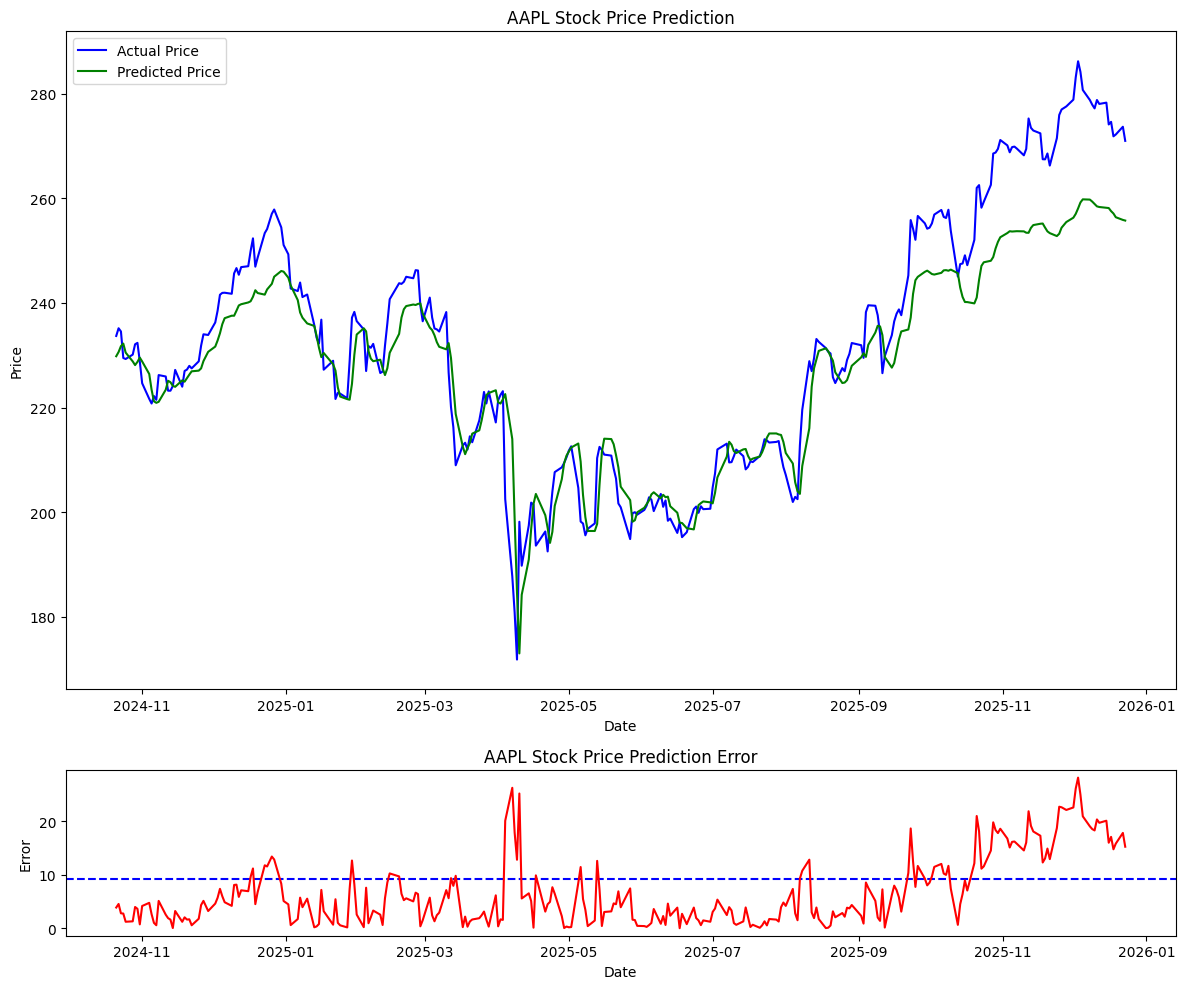

In [49]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(4, 1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = "blue", label = "Actual Price")
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = "green", label = "Predicted Price")
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = "blue", linestyle="--", label="RMSE")
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test - y_test_pred), color = "red", label = "Prediction Error")
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()

plt.show()